In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv
Saving marketing_campaign.csv to marketing_campaign.csv
Saving train.csv to train.csv


#Task 1: Credit Card Fraud Detection (Classification)
Dataset: Credit Card Fraud Detection (Kaggle)
Steps:
1. Load dataset
2. Handle class imbalance (undersampling/oversampling)
3. Apply feature scaling
4. Split data (70/30)

Models:
- Logistic Regression
- Random Forest

Evaluation:
- Accuracy
- Precision
- Recall
- F1-score

Deliverables:
- Model comparison
- Identify best model for imbalanced data

Logistic Regression/n
Accuracy: 0.9291
Precision 0.9669
Recall: 0.8731
F1-Score: 0.9176
Random Forest

Accuracy: 0.9291
Precision: 0.9829
Recall:: 0.8582
F1-Score: 0.9163


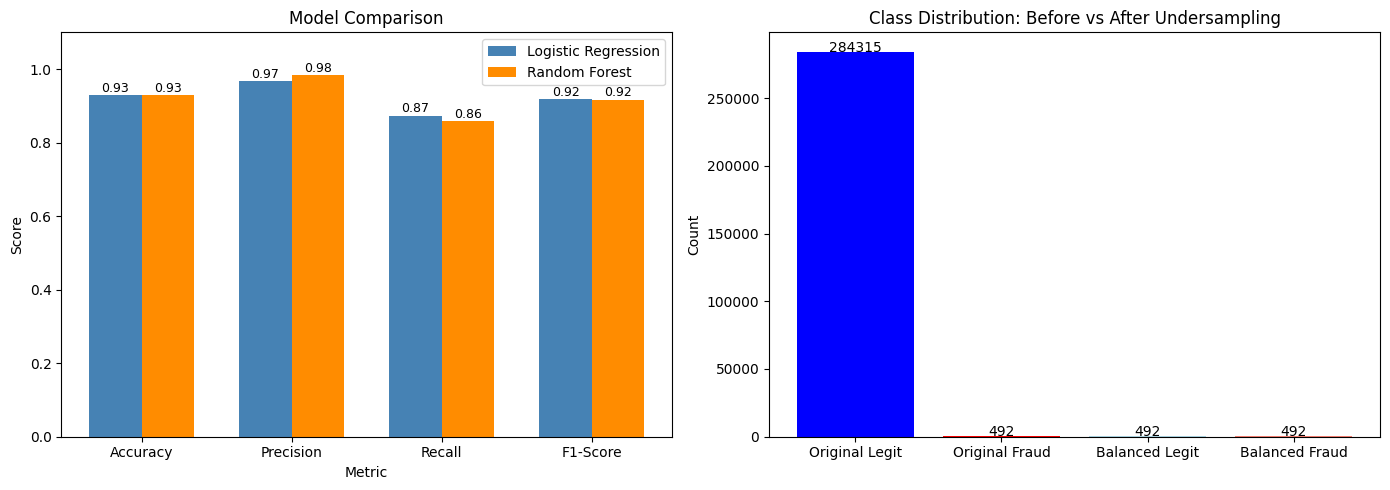


Best model: Logistic Regression
(Random Forest F1=0.9163, Logistic Regression F1=0.9176)


In [31]:
df_fraud = pd.read_csv('creditcard.csv')
fraud_df = df_fraud[df_fraud['Class'] == 1]
legit_df = df_fraud[df_fraud['Class'] == 0]
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)
balanced_df = pd.concat([legit_sample, fraud_df])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.30, random_state=42)

#models
print("Logistic Regression/n")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Accuracy: {lr_acc:.4f}")
print(f"Precision {lr_prec:.4f}")
print(f"Recall: {lr_rec:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

print("Random Forest\n")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy: {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:: {rf_rec:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]
x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='darkorange')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, (lr, rf) in enumerate(zip(lr_scores, rf_scores)):
    axes[0].text(i - width/2, lr + 0.01, f'{lr:.2f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, rf + 0.01, f'{rf:.2f}', ha='center', fontsize=9)

n_legit = len(legit_df)
n_fraud = len(fraud_df)

axes[1].bar(['Original Legit', 'Original Fraud', 'Balanced Legit', 'Balanced Fraud'], [n_legit, n_fraud, len(legit_sample), len(fraud_df)],
            color=['blue', 'red', 'lightblue', 'salmon'])
axes[1].set_title('Class Distribution: Before vs After Undersampling')
axes[1].set_ylabel('Count')
for i, v in enumerate([n_legit, n_fraud, len(legit_sample), len(fraud_df)]):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBest model: {'Random Forest' if rf_f1 > lr_f1 else 'Logistic Regression'}")
print(f"(Random Forest F1={rf_f1:.4f}, Logistic Regression F1={lr_f1:.4f})")


#Task 2: House Price Prediction (Regression)
Dataset: House Prices – Advanced Regression Techniques (Kaggle)

Steps:
1. Handle missing values
2. Encode categorical variables
3. Apply feature scaling

Models:
- Linear Regression
- Decision Tree Regressor

Evaluation:
- MAE
- RMSE

Deliverables:
- Predicted vs Actual comparison
- Best model identification

Remaining nulls: 7829
Linear Regression 
MAE: 22759.12
RMSE 34870.34
Decision Tree Regressor
MAE:26469.00
RMSE: 41472.16


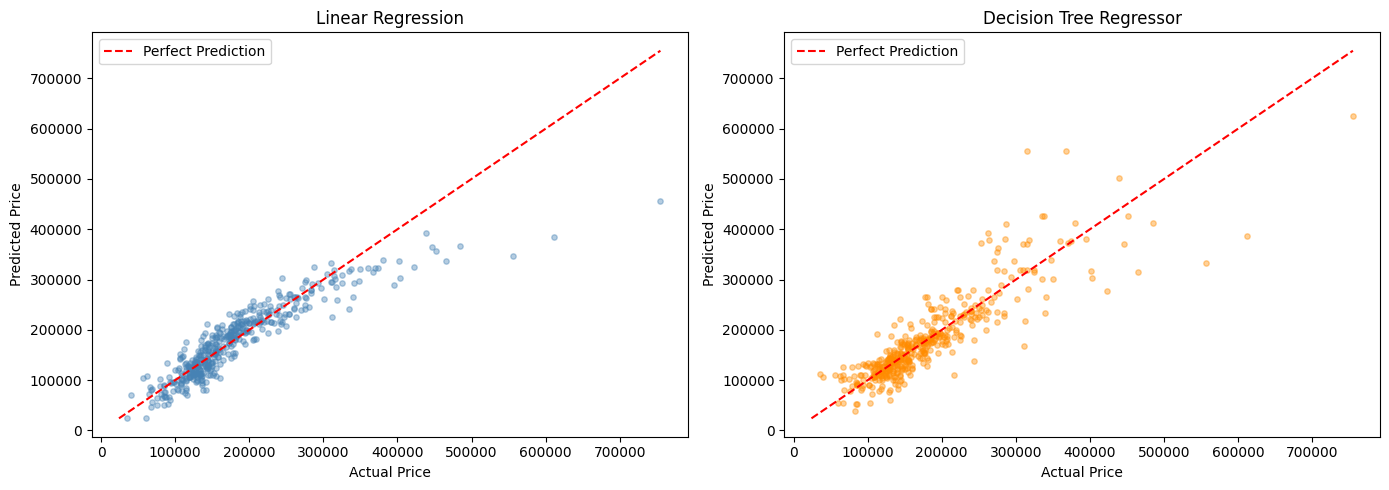


Best model: Linear Regression
(Lower RMSE is better: LR=34870.34, DT=41472.16)


In [32]:
df_house = pd.read_csv('train.csv')
df_house['GarageCars'] = df_house['GarageCars'].fillna(df_house['GarageCars'].median())
df_house['LotArea'] = df_house['LotArea'].fillna(df_house['LotArea'].median())
print(f"Remaining nulls: {df_house.isnull().sum().sum()}")

le = LabelEncoder()
for col in ['Neighborhood', 'BldgType', 'SaleCondition']:
    df_house[col] = le.fit_transform(df_house[col])
X_house = df_house.select_dtypes(include=[np.number]).drop('SalePrice', axis=1)
X_house = X_house.fillna(X_house.median())
y_house = df_house['SalePrice']

scaler_house = StandardScaler()
X_house_scaled = scaler_house.fit_transform(X_house)
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_house_scaled, y_house, test_size=0.30, random_state=42)

print("Linear Regression ")
lr_reg = LinearRegression()
lr_reg.fit(X_h_train, y_h_train)
lr_reg_pred = lr_reg.predict(X_h_test)
lr_mae = mean_absolute_error(y_h_test, lr_reg_pred)
lr_rmse = np.sqrt(mean_squared_error(y_h_test, lr_reg_pred))
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE {lr_rmse:.2f}")

print("Decision Tree Regressor")
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_h_train, y_h_train)
dt_reg_pred = dt_reg.predict(X_h_test)
dt_mae = mean_absolute_error(y_h_test, dt_reg_pred)
dt_rmse = np.sqrt(mean_squared_error(y_h_test, dt_reg_pred))
print(f"MAE:{dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_h_test, lr_reg_pred, alpha=0.4, color='steelblue', s=15)
min_val = min(y_h_test.min(), lr_reg_pred.min())
max_val = max(y_h_test.max(), lr_reg_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression')
axes[0].legend()

axes[1].scatter(y_h_test, dt_reg_pred, alpha=0.4, color='darkorange', s=15)
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Decision Tree Regressor')
axes[1].legend()

plt.tight_layout()
plt.show()
best_reg = 'Linear Regression' if lr_rmse < dt_rmse else 'Decision Tree Regressor'
print(f"\nBest model: {best_reg}")
print(f"(Lower RMSE is better: LR={lr_rmse:.2f}, DT={dt_rmse:.2f})")


#Task 3: Customer Segmentation
Dataset: Customer Personality Analysis (Kaggle)

Steps:
1. Select relevant features
2. Handle missing values
3. Apply Standard Scaling

Apply:
- K-Means clustering
- Elbow Method (K = 2–10)

Deliverables:
- Elbow graph
- Cluster visualization
- Cluster labels

  K=2: WCSS = 19091.27
  K=3: WCSS = 16497.40
  K=4: WCSS = 15443.81
  K=5: WCSS = 15018.26
  K=6: WCSS = 14047.64
  K=7: WCSS = 13485.75
  K=8: WCSS = 13050.82
  K=9: WCSS = 12548.28
  K=10: WCSS = 12194.73


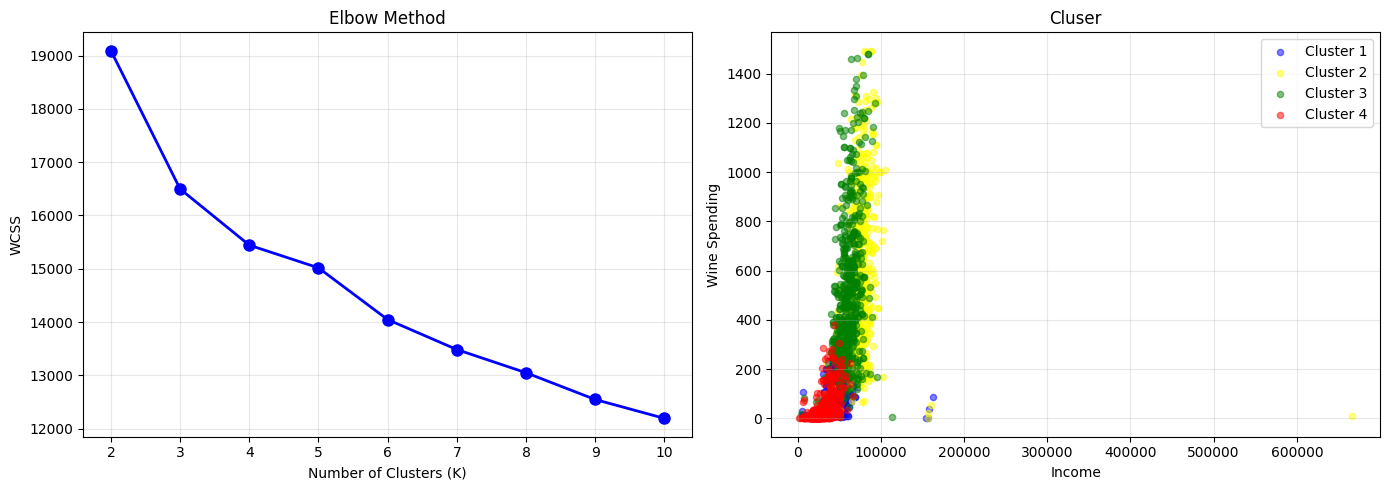

Cluster 1    525
Cluster 2    534
Cluster 3    585
Cluster 4    596
Name: count, dtype: int64


In [30]:
df_cust = pd.read_csv('marketing_campaign.csv', sep='\t')
features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
            'MntGoldProds', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'Kidhome', 'Teenhome']
df_seg = df_cust[features].copy()
df_seg['Income'] = df_seg['Income'].fillna(df_seg['Income'].median())
scaler_cust = StandardScaler()
X_cust = scaler_cust.fit_transform(df_seg)

wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_cust)
    wcss.append(kmeans.inertia_)
    print(f"  K={k}: WCSS = {kmeans.inertia_:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), wcss, marker='o', color='blue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

optimal_k = 4


kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(X_cust)
df_seg['Cluster'] = cluster_labels

colors = ['blue', 'yellow', 'green', 'red']
for i in range(optimal_k):
    mask = cluster_labels == i
    axes[1].scatter(df_seg.loc[mask, 'Income'],df_seg.loc[mask, 'MntWines'],s=20, alpha=0.5, c=colors[i], label=f'Cluster {i + 1}')

axes[1].set_xlabel('Income')
axes[1].set_ylabel('Wine Spending')
axes[1].set_title(f'Cluser')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(pd.Series(cluster_labels).value_counts().sort_index().rename(lambda x: f'Cluster {x+1}'))
